In [1]:
# Mount google drive and move to dataset folder
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/iot/pad_ufes_20
%ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/iot/pad_ufes_20
images/  metadata.csv


In [73]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

import torch
import torchvision.transforms as T

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 1) Load data and split first (anti-leakage)

All preprocessing steps below are fit only on the training split, then applied to test with `.transform()`.

In [36]:
pad_dataset = pd.read_csv('metadata.csv')
print(pad_dataset.shape)
pad_dataset.head()

(2298, 26)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARM,NaN,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FACE,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HAND,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,False,False,False,1.0,FOREARM,5.0,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [37]:
pad_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
lesion_id,2298.0,1529.933856,1196.285644,6.0,720.5,1297.0,1782.75,4820.0
age,2298.0,60.464752,15.894866,6.0,52.0,62.0,72.00,94.0
fitspatrick,1494.0,2.265730,0.729029,1.0,2.0,2.0,3.00,6.0
diameter_1,1494.0,11.897055,8.634492,0.0,7.0,10.0,15.00,100.0
diameter_2,1494.0,8.852209,5.797036,0.0,5.0,8.0,10.00,70.0


In [38]:
# msh ai sare2ha mn stackoverflow
buffer = io.StringIO()
pad_dataset.info(buf=buffer)
lines = buffer.getvalue().splitlines()
pad_dataset_info = (pd.DataFrame([x.split() for x in lines[5:-2]], columns=lines[3].split())
       .drop(['Count', '#'],axis=1)
       .rename(columns={'Non-Null':'Non-Null Count'}))

pad_dataset_info   

,Column,Non-Null Count,Dtype
0,patient_id,2298,object
1,lesion_id,2298,int64
2,smoke,1494,object
3,drink,1494,object
4,background_father,1480,object
5,background_mother,1476,object
6,age,2298,int64
7,pesticide,1494,object
8,gender,1494,object
9,skin_cancer_history,1494,object


In [39]:
pad_dataset['patient_id'].value_counts().head()

,count
patient_id,
PAT_388,10
PAT_645,10
PAT_330,10
PAT_53,7
PAT_1414,7


In [40]:
target_col = 'diagnostic'
groups = pad_dataset['patient_id']

# Stratified + group-aware split (patient-level, class-balanced as much as possible)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(pad_dataset, y=pad_dataset[target_col], groups=groups))

train_df = pad_dataset.iloc[train_idx].reset_index(drop=True)
test_df = pad_dataset.iloc[test_idx].reset_index(drop=True)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print('Train classes:')
display(train_df[target_col].value_counts())
print('Test classes:')
display(test_df[target_col].value_counts())

train_pct = train_df[target_col].value_counts(normalize=True).rename('train_pct')
test_pct = test_df[target_col].value_counts(normalize=True).rename('test_pct')
class_compare = pd.concat([train_pct, test_pct], axis=1).fillna(0)
class_compare['abs_diff'] = (class_compare['train_pct'] - class_compare['test_pct']).abs()
display(class_compare.sort_values('abs_diff', ascending=False))

Train shape: (1838, 26)
Test shape:  (460, 26)
Train classes:


,count
diagnostic,
BCC,672
ACK,586
NEV,199
SEK,187
SCC,155
MEL,39


Test classes:


,count
diagnostic,
BCC,173
ACK,144
SEK,48
NEV,45
SCC,37
MEL,13


,train_pct,test_pct,abs_diff
diagnostic,,,
BCC,0.365615,0.376087,0.010472
NEV,0.108270,0.097826,0.010444
MEL,0.021219,0.028261,0.007042
ACK,0.318825,0.313043,0.005781
SCC,0.084331,0.080435,0.003896
SEK,0.101741,0.104348,0.002607


## 2) Null exploration on TRAIN only

,Null %
background_mother,35.96
background_father,35.75
pesticide,35.15
gender,35.15
drink,35.15
smoke,35.15
skin_cancer_history,35.15
has_sewage_system,35.15
has_piped_water,35.15
cancer_history,35.15


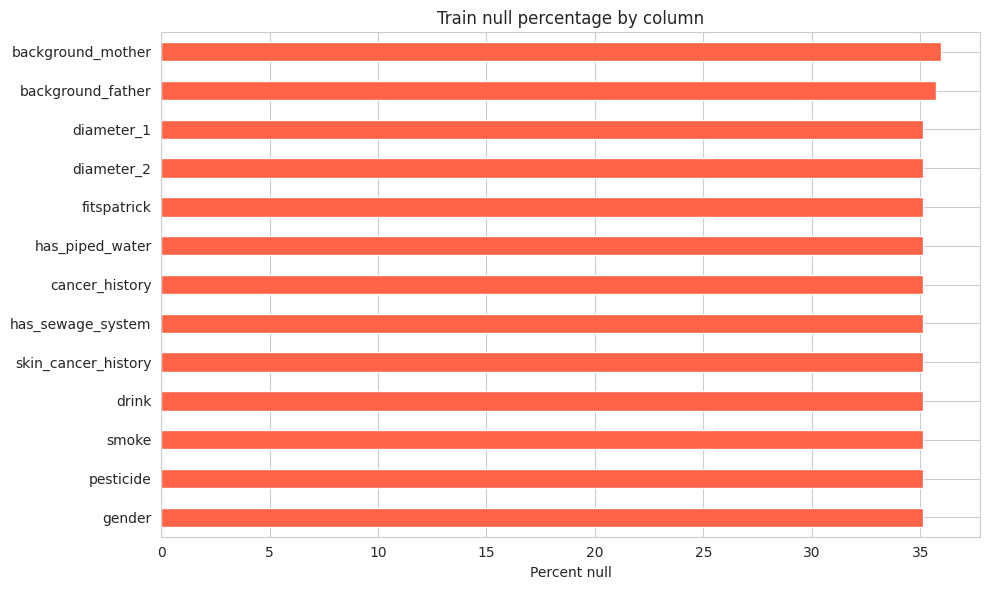

In [41]:
train_null_pct = (train_df.isnull().mean() * 100).round(2).sort_values(ascending=False)
train_null_pct = train_null_pct[train_null_pct > 0]
display(train_null_pct.to_frame('Null %'))

plt.figure(figsize=(10, 6))
train_null_pct.sort_values().plot(kind='barh', color='tomato')
plt.title('Train null percentage by column')
plt.xlabel('Percent null')
plt.tight_layout()
plt.show()

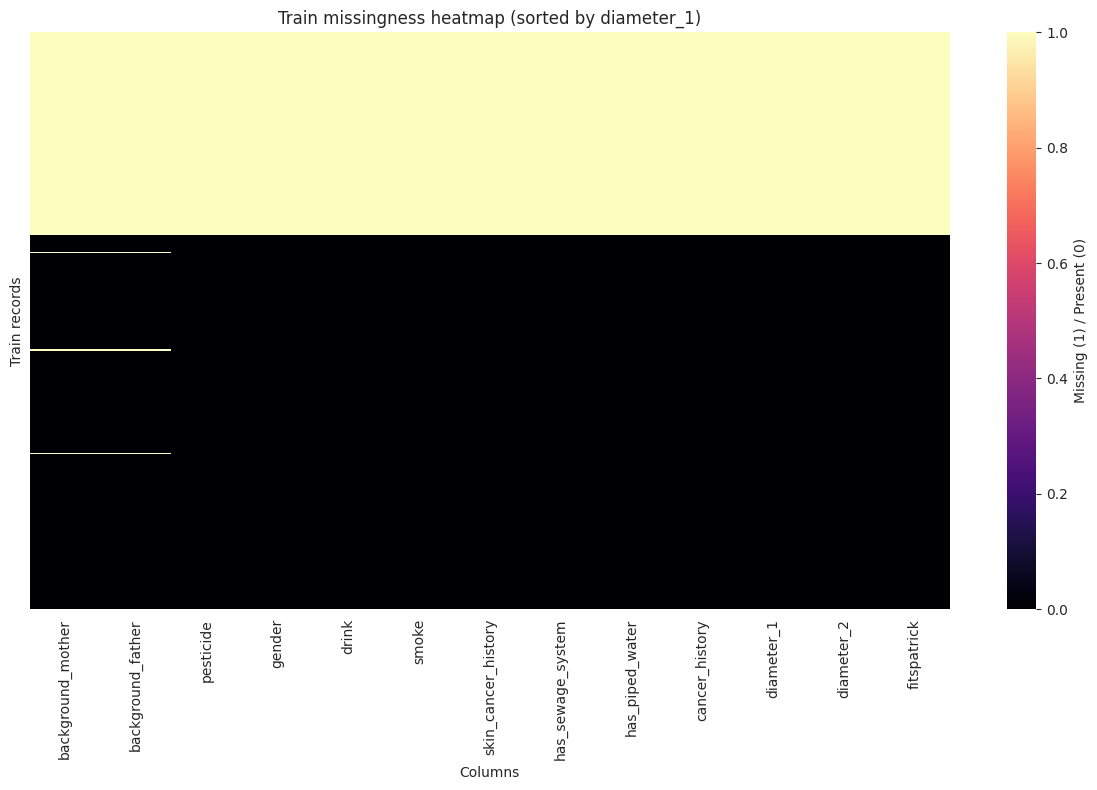

Records missing all high-null columns: 646 / 1838 (35.15%)


In [51]:
high_null_cols = train_null_pct[train_null_pct >= 30].index.tolist()
missing_matrix = train_df[high_null_cols].isnull().astype(int)

sort_col = 'diameter_1' if 'diameter_1' in high_null_cols else high_null_cols[0]
missing_matrix = missing_matrix.sort_values(by=sort_col, ascending=False)

plt.figure(figsize=(12, 8))
sns.heatmap(
    missing_matrix,
    cmap='magma',
    cbar_kws={'label': 'Missing (1) / Present (0)'},
    yticklabels=False
)
plt.title(f'Train missingness heatmap (sorted by {sort_col})')
plt.xlabel('Columns')
plt.ylabel('Train records')
plt.tight_layout()
plt.show()

rows_all_missing = (missing_matrix.sum(axis=1) == len(high_null_cols)).sum()
print(f'Records missing all high-null columns: {rows_all_missing} / {len(train_df)} ({rows_all_missing / len(train_df):.2%})')

## 3) Deep exploration on TRAIN (distribution, correlation, mutual information)

/tmp/ipykernel_105549/232068010.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=target_col, order=train_df[target_col].value_counts().index, palette='viridis')


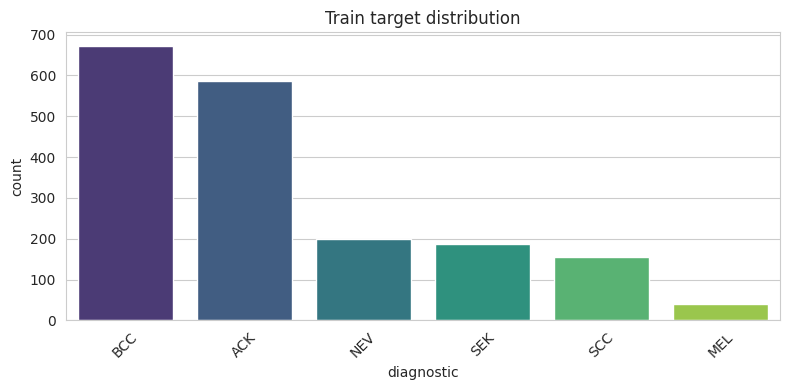

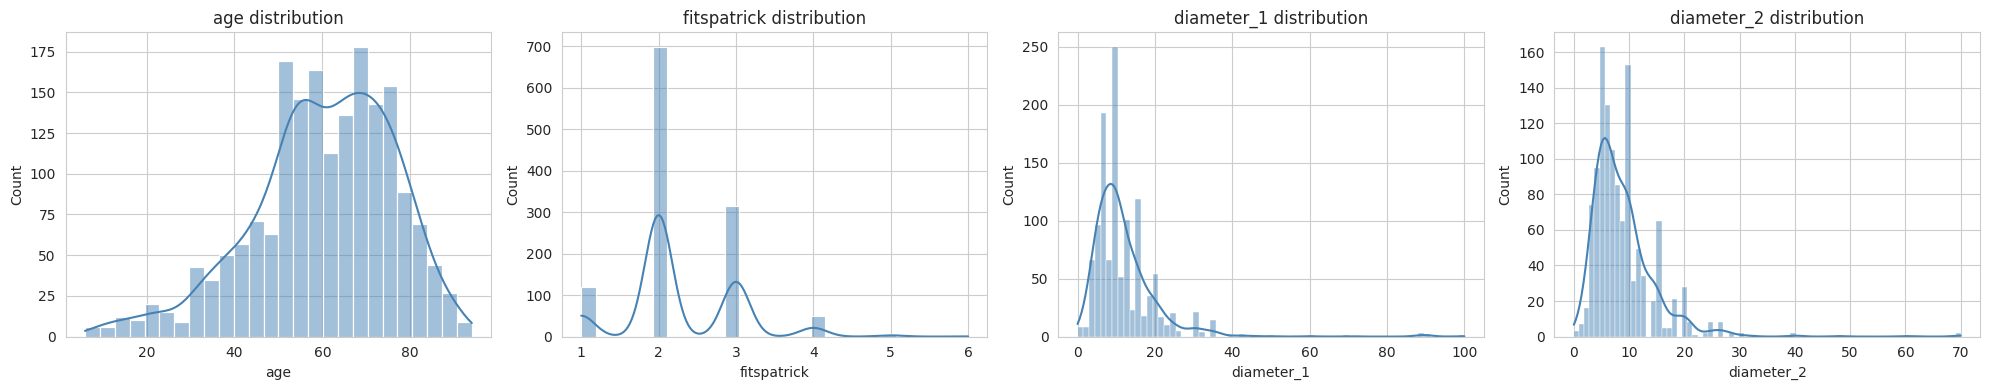

In [52]:
explore_drop_cols = ['diagnostic', 'img_id', 'patient_id', 'lesion_id']
explore_feature_cols = [c for c in train_df.columns if c not in explore_drop_cols]
explore_num_cols = train_df[explore_feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Target distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x=target_col, order=train_df[target_col].value_counts().index, palette='viridis')
plt.title('Train target distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Numeric feature distributions
if len(explore_num_cols) > 0:
    fig, axes = plt.subplots(1, len(explore_num_cols), figsize=(5 * len(explore_num_cols), 4))
    if len(explore_num_cols) == 1:
        axes = [axes]
    for i, col in enumerate(explore_num_cols):
        sns.histplot(train_df[col], kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

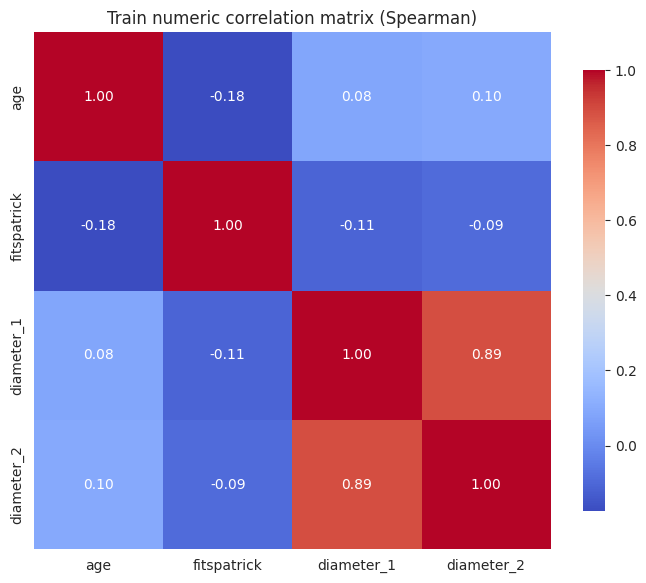

In [53]:
corr = train_df[explore_num_cols].corr(method='spearman')
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Train numeric correlation matrix (Spearman)')
plt.tight_layout()
plt.show()

,feature,mutual_info
86,cat__biopsed_True,0.414836
85,cat__biopsed_False,0.414836
34,cat__background_mother_nan,0.329083
23,cat__background_father_nan,0.326544
6,cat__smoke_nan,0.316559
9,cat__drink_nan,0.316559
49,cat__has_piped_water_nan,0.316559
52,cat__has_sewage_system_nan,0.316559
37,cat__pesticide_nan,0.316559
46,cat__cancer_history_nan,0.316559


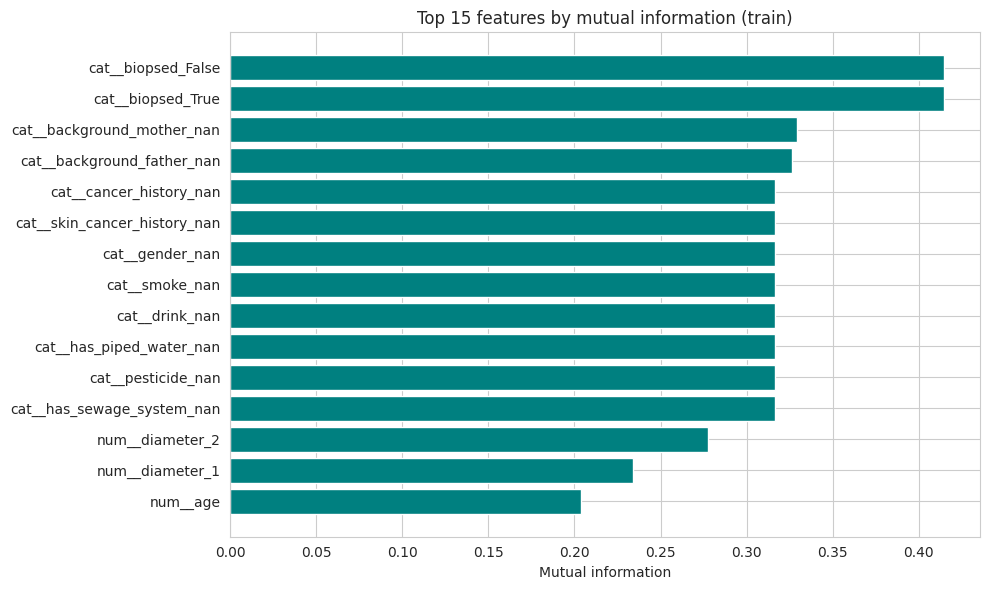

In [54]:
# MI on train only (fit encoders/imputers on train only)
mi_cat_cols = train_df[explore_feature_cols].select_dtypes(include=['object', 'bool']).columns.tolist()
mi_num_cols = train_df[explore_feature_cols].select_dtypes(include=[np.number]).columns.tolist()

mi_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), mi_num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), mi_cat_cols)
], remainder='drop')

X_train_mi_input = train_df[explore_feature_cols].copy()
X_train_mi_input[mi_cat_cols] = X_train_mi_input[mi_cat_cols].astype(str)
X_train_mi = mi_preprocessor.fit_transform(X_train_mi_input)
label_encoder = LabelEncoder()
y_train_mi = label_encoder.fit_transform(train_df[target_col])

n_num = len(mi_num_cols)
n_total = X_train_mi.shape[1]
discrete_mask = np.array([False] * n_num + [True] * (n_total - n_num))

mi_scores = mutual_info_classif(X_train_mi, y_train_mi, discrete_features=discrete_mask, random_state=42)
feature_names = mi_preprocessor.get_feature_names_out()
mi_df = pd.DataFrame({'feature': feature_names, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)

display(mi_df.head(20))

plt.figure(figsize=(10, 6))
top_mi = mi_df.head(15).sort_values('mutual_info')
plt.barh(top_mi['feature'], top_mi['mutual_info'], color='teal')
plt.title('Top 15 features by mutual information (train)')
plt.xlabel('Mutual information')
plt.tight_layout()
plt.show()

### Interpretation Notes (Class Distribution, Correlation, MI)

- **Class distribution:** your stratified group split is the right choice; keep checking the train/test percentage gap (`abs_diff`) to make sure minority classes remain represented.
- **Correlation matrix:** focus on pairs like `diameter_1` vs `diameter_2` (often highly correlated). For deep models this is usually fine; for linear models you might drop one if instability appears.
- **Current preprocessing choice:** `diameter_1` and `diameter_2` are standardized; `age` and `fitspatrick` are median-imputed but not outlier-filtered.
- **Mutual information:** strongest features are `biopsed` and missingness-related indicators (`*_nan`). This suggests missingness is informative (history-not-taken cohort), so preserving missingness patterns is useful.
- **Important caution:** if `biopsed` is post-decision or clinically downstream from diagnosis, remove it from training to avoid shortcut/label leakage in diagnostic prediction tasks.

## 4) Tabular preprocessing with fit/transform and outlier handling

- Fit preprocessors on train only.
- Transform train and test with the fitted objects.
- Standardize only `diameter_1` and `diameter_2`; keep `age` and `fitspatrick` unscaled (median-imputed).
- Fit outlier detector on train only using diameter columns; keep all rows in both train and test (flag-only analysis).

In [55]:
target_col = 'diagnostic'
# `img_id`/`patient_id` are excluded from tabular feature engineering,
# but they are kept later in exported CSVs for image-metadata fusion.
drop_cols = ['diagnostic', 'img_id', 'patient_id', 'lesion_id']
feature_cols = [c for c in train_df.columns if c not in drop_cols]

cat_cols = train_df[feature_cols].select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = train_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Only normalize diameter columns; keep other numeric columns imputed but unscaled
diameter_cols = [c for c in ['diameter_1', 'diameter_2'] if c in num_cols]
other_num_cols = [c for c in num_cols if c not in diameter_cols]

print('Categorical columns:', cat_cols)
print('Numeric columns:', num_cols)
print('Diameter columns (scaled):', diameter_cols)
print('Other numeric columns (impute only):', other_num_cols)

Categorical columns: ['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'region', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']
Numeric columns: ['age', 'fitspatrick', 'diameter_1', 'diameter_2']
Diameter columns (scaled): ['diameter_1', 'diameter_2']
Other numeric columns (impute only): ['age', 'fitspatrick']


In [56]:
diameter_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

other_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

transformers = []
if len(diameter_cols) > 0:
    transformers.append(('num_diam', diameter_pipeline, diameter_cols))
if len(other_num_cols) > 0:
    transformers.append(('num_other', other_numeric_pipeline, other_num_cols))
transformers.append(('cat', categorical_pipeline, cat_cols))

preprocessor = ColumnTransformer(transformers, remainder='drop')

X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()
X_train_raw[cat_cols] = X_train_raw[cat_cols].astype(str)
X_test_raw[cat_cols] = X_test_raw[cat_cols].astype(str)
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (1838, 87)
X_test shape:  (460, 87)


In [57]:
# Outlier detection only on diameter columns (exclude age and fitspatrick)
outlier_cols = [c for c in ['diameter_1', 'diameter_2'] if c in X_train_raw.columns]
outlier_scaler = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

if len(outlier_cols) > 0:
    X_train_num = outlier_scaler.fit_transform(X_train_raw[outlier_cols])
    X_test_num = outlier_scaler.transform(X_test_raw[outlier_cols])

    iso = IsolationForest(contamination=0.05, random_state=42)
    train_outlier_flag = iso.fit_predict(X_train_num)
    test_outlier_flag = iso.predict(X_test_num)
else:
    train_outlier_flag = np.ones(len(X_train_raw), dtype=int)
    test_outlier_flag = np.ones(len(X_test_raw), dtype=int)

train_inlier_mask = train_outlier_flag == 1

# Keep all rows (do not remove outliers from train/test)
X_train_filtered = X_train
y_train_filtered = y_train.reset_index(drop=True)

print('Outlier columns used:', outlier_cols)
print('Train inliers:', (train_outlier_flag == 1).sum())
print('Train outliers:', (train_outlier_flag == -1).sum())
print('Test predicted outliers (not removed):', (test_outlier_flag == -1).sum())
print('Train shape kept (no outlier removal):', X_train_filtered.shape)

Outlier columns used: ['diameter_1', 'diameter_2']
Train inliers: 1746
Train outliers: 92
Test predicted outliers (not removed): 15
Train shape kept (no outlier removal): (1838, 87)


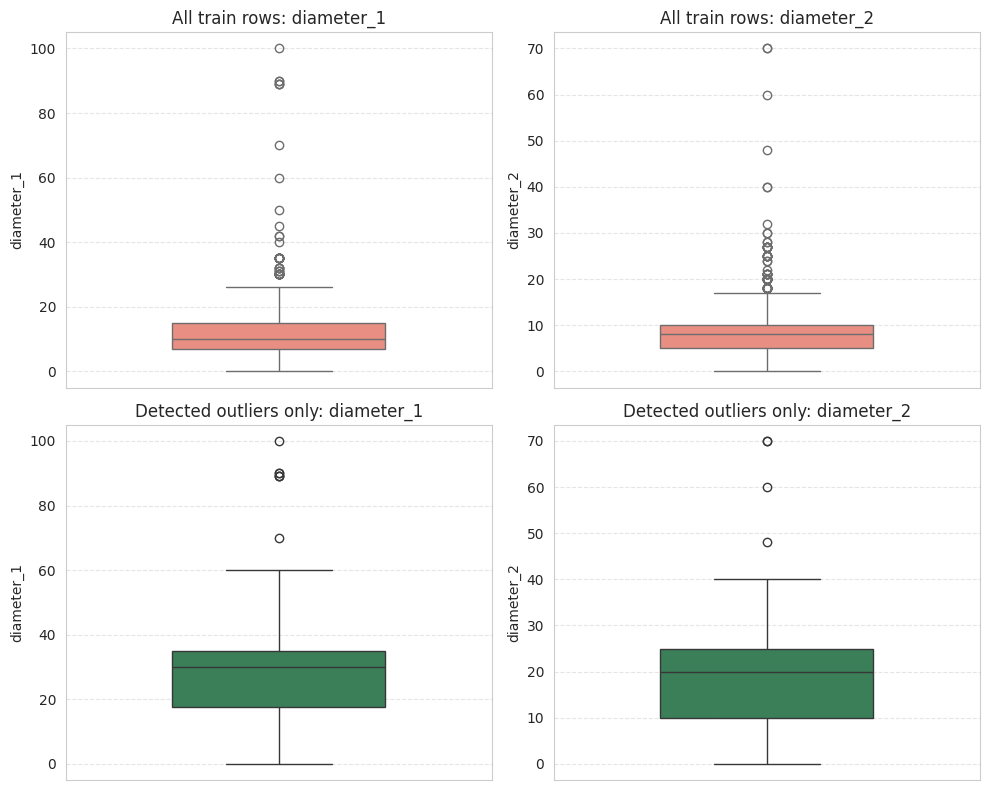

In [58]:
# Boxplots for all train rows vs detected outlier subset (no removal)
train_outlier_df = train_df.loc[~train_inlier_mask].reset_index(drop=True)

plot_cols = outlier_cols if len(outlier_cols) > 0 else num_cols
fig, axes = plt.subplots(2, len(plot_cols), figsize=(5 * len(plot_cols), 8))
if len(plot_cols) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, col in enumerate(plot_cols):
    sns.boxplot(y=train_df[col], ax=axes[0, i], color='salmon', width=0.5)
    axes[0, i].set_title(f'All train rows: {col}')
    axes[0, i].grid(True, axis='y', linestyle='--', alpha=0.5)

    sns.boxplot(y=train_outlier_df[col], ax=axes[1, i], color='seagreen', width=0.5)
    axes[1, i].set_title(f'Detected outliers only: {col}')
    axes[1, i].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Z-score visualization for diameter columns (before vs after)

Raw diameter statistics:


,diameter_1,diameter_2
count,1192.000000,1192.000000
mean,11.993289,8.913591
std,9.053806,5.978839
min,0.000000,0.000000
25%,7.000000,5.000000
50%,10.000000,8.000000
75%,15.000000,10.000000
max,100.000000,70.000000


Z-score diameter statistics:


,diameter_1,diameter_2
count,1.838000e+03,1.838000e+03
mean,-3.865847e-17,9.278034e-17
std,1.000272e+00,1.000272e+00
min,-1.536429e+00,-1.778046e+00
25%,-3.119346e-01,-5.364647e-01
50%,-1.758796e-01,-1.226044e-01
75%,-3.982458e-02,8.432573e-02
max,1.206907e+01,1.270707e+01


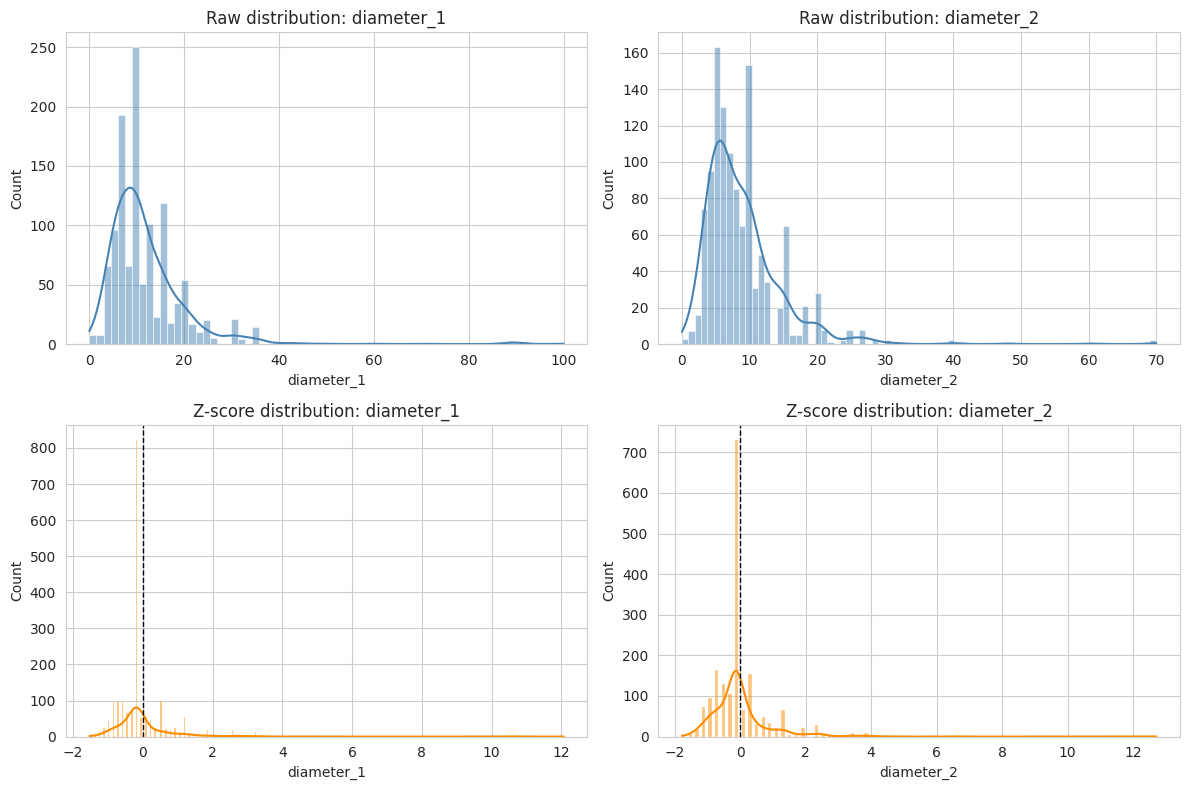

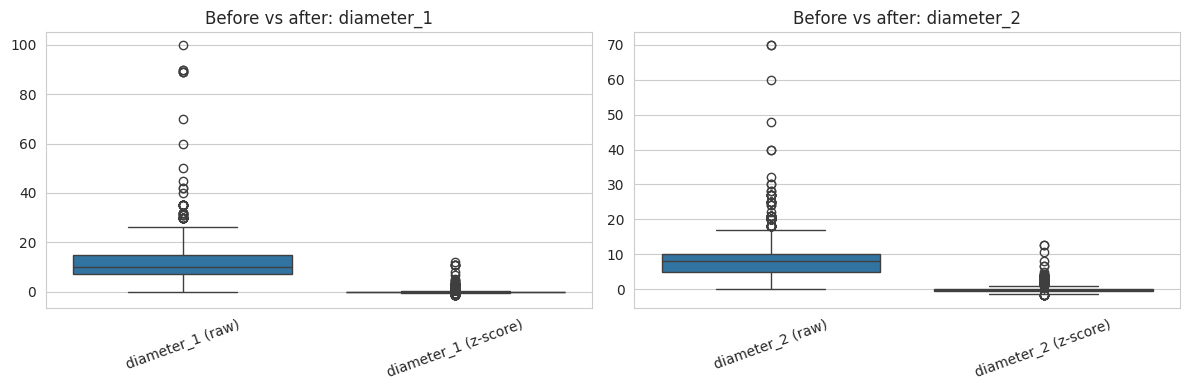

In [59]:
# Visualize raw vs z-scored diameter columns used by outlier detector
if len(outlier_cols) > 0:
    scaled_diam_df = pd.DataFrame(X_train_num, columns=outlier_cols)

    print('Raw diameter statistics:')
    display(X_train_raw[outlier_cols].describe())

    print('Z-score diameter statistics:')
    display(scaled_diam_df.describe())

    fig, axes = plt.subplots(2, len(outlier_cols), figsize=(6 * len(outlier_cols), 8))
    if len(outlier_cols) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, col in enumerate(outlier_cols):
        sns.histplot(X_train_raw[col], kde=True, ax=axes[0, i], color='steelblue')
        axes[0, i].set_title(f'Raw distribution: {col}')

        sns.histplot(scaled_diam_df[col], kde=True, ax=axes[1, i], color='darkorange')
        axes[1, i].set_title(f'Z-score distribution: {col}')
        axes[1, i].axvline(0, color='black', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, len(outlier_cols), figsize=(6 * len(outlier_cols), 4))
    if len(outlier_cols) == 1:
        axes = [axes]

    for i, col in enumerate(outlier_cols):
        compare_df = pd.DataFrame({
            f'{col} (raw)': X_train_raw[col].values,
            f'{col} (z-score)': scaled_diam_df[col].values
        })
        sns.boxplot(data=compare_df, ax=axes[i])
        axes[i].set_title(f'Before vs after: {col}')
        axes[i].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print('No diameter columns available for z-score visualization.')

### Should You Handle Outliers? (All Practical Options)

You found ~5% train outliers (`92 / 1838`), which is moderate. In this notebook, outlier detection is diameter-only (`diameter_1`, `diameter_2`) and excludes `age`/`fitspatrick`, and we keep all rows (no removal). Compare validation performance under these choices:

1. **Keep all rows (recommended baseline)**: simplest and often robust for CNN/Transformer + fusion.
2. **Current approach (flag-only, diameter-only detector)**: detect and inspect outliers but keep both train and test unchanged.
3. **Winsorize/cap tails**: clip numeric columns at percentile bounds (e.g., 1st/99th) instead of removing rows.
4. **Robust scaling only**: use `RobustScaler` to reduce outlier influence without deleting samples.
5. **Sample-weighting**: keep all rows but down-weight high anomaly-score samples.
6. **Class-conditional detection**: detect outliers per class so rare classes are not disproportionately removed.

For medical data, avoid aggressive pruning first; rare/extreme cases can be clinically meaningful.

## 5) Image exploration (one image per class + shape statistics)

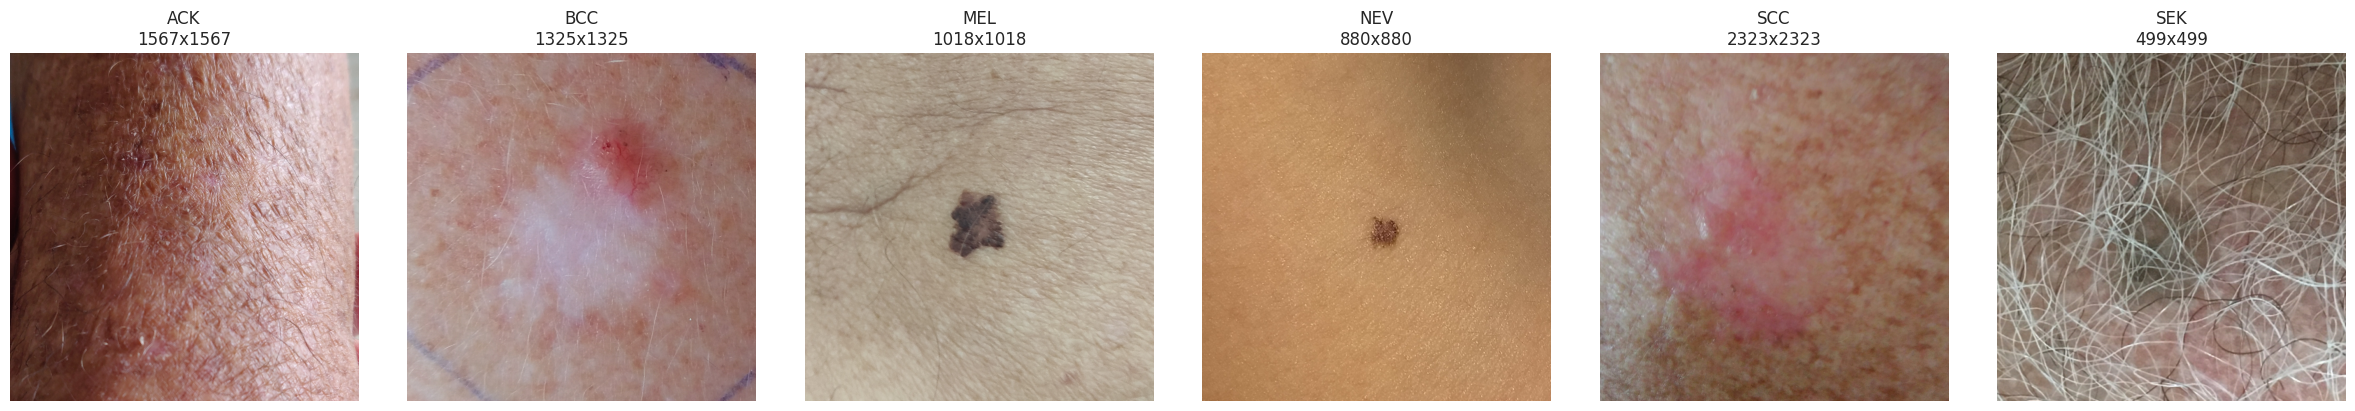

In [60]:
images_dir = Path('images')

def get_existing_path(img_name):
    p = images_dir / str(img_name)
    return p if p.is_file() else None

class_sample_paths = {}
for label in sorted(train_df['diagnostic'].dropna().unique()):
    rows = train_df[train_df['diagnostic'] == label]
    found = None
    for img_name in rows['img_id']:
        p = get_existing_path(img_name)
        if p is not None:
            found = p
            break
    class_sample_paths[label] = found

n_classes = len(class_sample_paths)
fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4))
if n_classes == 1:
    axes = [axes]

for ax, (label, path) in zip(axes, class_sample_paths.items()):
    if path is None:
        ax.text(0.5, 0.5, f'No image\nfor {label}', ha='center', va='center')
        ax.axis('off')
        continue
    img = Image.open(path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'{label}\n{img.size[0]}x{img.size[1]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
width,400.0,935.8825,522.072507,167.0,555.5,756.0,1219.75,2927.0
height,400.0,935.5875,522.302006,167.0,555.5,756.0,1219.75,2927.0


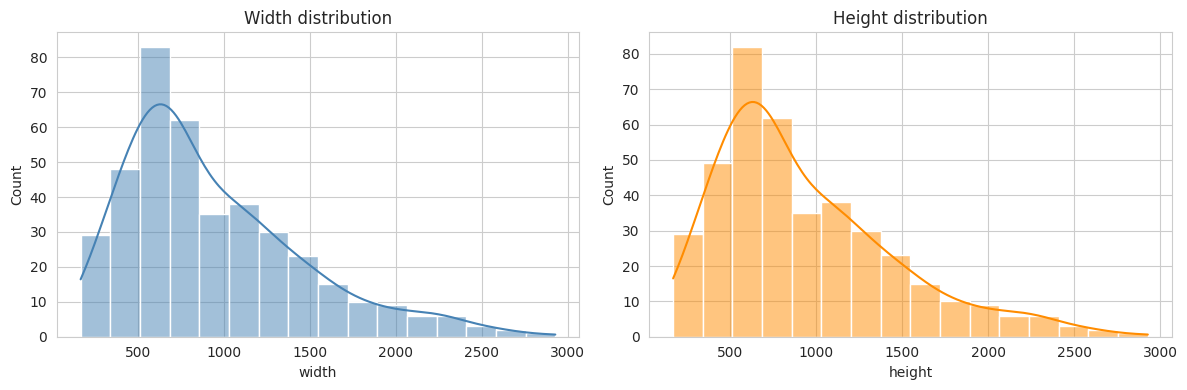

In [36]:
sample_paths = []
for img_name in train_df['img_id']:
    p = get_existing_path(img_name)
    if p is not None:
        sample_paths.append(p)

sample_paths = sample_paths[:400]
sizes = []
for p in sample_paths:
    with Image.open(p) as im:
        w, h = im.size
        sizes.append((w, h))

sizes_df = pd.DataFrame(sizes, columns=['width', 'height'])
display(sizes_df.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sizes_df['width'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Width distribution')
sns.histplot(sizes_df['height'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Height distribution')
plt.tight_layout()
plt.show()

### Is 167x167 -> 224x224 okay?

Yes, it is generally okay. Upscaling from 167 to 224 is about **1.34x**, which is a moderate resize and commonly acceptable for CNN/Transformer pipelines.

- Keep using augmentation + normalization (already configured).
- Prefer crop-based resizing (`RandomResizedCrop`) to avoid heavy geometric distortion.
- If many images are very small and blur becomes noticeable, compare training at `192x192` for a speed/detail tradeoff.

## 6) Image preprocessing pipelines for CNN and Transformer

In [70]:
# Unified image preprocessing for both CNN and Transformer
common_train_tfms = T.Compose([
    T.Resize((256, 256)),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

common_eval_tfms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Reuse same transforms for both model families

# Quick sanity check on one image
example_path = next((get_existing_path(x) for x in train_df['img_id'] if get_existing_path(x) is not None), None)
if example_path is not None:
    img = Image.open(example_path).convert('RGB')
    image_tensor = common_eval_tfms(img)
    print('Example image:', example_path.name)
    print('Image tensor shape:', tuple(image_tensor.shape))

Example image: PAT_46_881_939.png
Image tensor shape: (3, 224, 224)


## 7) Final summary and export for training

### What was done
- Loaded metadata and performed **stratified + group-aware split** (`diagnostic` stratification, `patient_id` grouping).
- Explored missingness on train split and visualized null-pattern alignment with heatmap.
- Ran deep exploration (class distribution, correlation matrix, mutual information).
- Built leakage-safe tabular preprocessing with `fit` on train and `transform` on test.
- Used **z-score standardization** for `diameter_1` and `diameter_2`.
- Kept `age` and `fitspatrick` without outlier filtering; outliers are only flagged (no row removal).
- Explored image samples per class, image-size distribution, and defined unified image transforms for CNN/Transformer.
- Visualized samples after preprocessing and exported preprocessed image tensors (normalized) for train/test.

Next cells export processed train/test tabular files and preprocessed images so training can load directly from disk.

In [74]:
# Export preprocessed images as tensors (with normalization retained)
processed_img_root = Path('processed_images')
train_img_dir = processed_img_root / 'train_tensors'
test_img_dir = processed_img_root / 'test_tensors'
train_img_dir.mkdir(parents=True, exist_ok=True)
test_img_dir.mkdir(parents=True, exist_ok=True)

def save_preprocessed_set(df, output_dir, transform, split_name):
    saved = 0
    missing = 0
    for _, row in df.iterrows():
        src = get_existing_path(row['img_id'])
        if src is None:
            missing += 1
            continue

        img = Image.open(src).convert('RGB')
        tensor = transform(img)

        out_name = Path(row['img_id']).stem + '_prep.pt'
        torch.save(tensor, output_dir / out_name)
        saved += 1

    print(f'{split_name}: saved={saved}, missing_source={missing}, out_dir={output_dir}')

save_preprocessed_set(train_df, train_img_dir, common_train_tfms, 'train')
save_preprocessed_set(test_df, test_img_dir, common_eval_tfms, 'test')

train: saved=1838, missing_source=0, out_dir=processed_images/train_tensors
test: saved=460, missing_source=0, out_dir=processed_images/test_tensors


In [72]:
export_dir = Path('processed')
export_dir.mkdir(parents=True, exist_ok=True)

# 1) Use already-prepared matrices from above (no re-cleaning pass)
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# 2) Add labels and identifiers only (no extra label encoding, no outlier flag export)
train_export_df = X_train_df.copy()
test_export_df = X_test_df.copy()

train_export_df['label_raw'] = y_train.reset_index(drop=True)
test_export_df['label_raw'] = y_test.reset_index(drop=True)

train_export_df['img_id'] = train_df['img_id'].reset_index(drop=True)
test_export_df['img_id'] = test_df['img_id'].reset_index(drop=True)
train_export_df['patient_id'] = train_df['patient_id'].reset_index(drop=True)
test_export_df['patient_id'] = test_df['patient_id'].reset_index(drop=True)

# Put identifier columns first for easier fusion dataloader usage
train_export_df = train_export_df[['img_id', 'patient_id', 'label_raw'] + [c for c in train_export_df.columns if c not in ['img_id', 'patient_id', 'label_raw']]]
test_export_df = test_export_df[['img_id', 'patient_id', 'label_raw'] + [c for c in test_export_df.columns if c not in ['img_id', 'patient_id', 'label_raw']]]

# 3) Save processed train/test datasets to CSV for direct training input
train_csv = export_dir / 'train_tabular_processed.csv'
test_csv = export_dir / 'test_tabular_processed.csv'
train_export_df.to_csv(train_csv, index=False)
test_export_df.to_csv(test_csv, index=False)

# 4) Print summary so the next training script can load these paths directly
print('Saved processed tabular datasets:')
print('-', train_csv)
print('-', test_csv)

print('\nProcessed train shape:', train_export_df.shape)
print('Processed test shape :', test_export_df.shape)
print('img_id kept for fusion:', 'img_id' in train_export_df.columns and 'img_id' in test_export_df.columns)

Saved processed tabular datasets:
- processed/train_tabular_processed.csv
- processed/test_tabular_processed.csv

Processed train shape: (1838, 90)
Processed test shape : (460, 90)
img_id kept for fusion: True
